<a href="https://colab.research.google.com/github/AlHartMos/IEU_courses/blob/main/simulating_and_modeling/Model_Building_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Building Exercises

We will explore the `swiss` dataset for this set of exercises. Below you can find the documentation about this dataset:

## Swiss Fertility and Socioeconomic Indicators (1888) Data

### Download the data

click [swiss](https://drive.google.com/file/d/1rB-pw1amgN-00mtGT6sd1rE3Y3QBpqzW/view?usp=share_link) to download the original dataset.

### Description
Standardized fertility measure and socio-economic indicators for each of 47 French-speaking provinces of Switzerland at about 1888.

### Format
A data frame with 47 observations on 6 variables, each of which is in percentages.

* `[,1]`	`Fertility`	$I_g$ (common standardized fertility measure)
* `[,2]`	`Agriculture`	% of males involved in agriculture as occupation
* `[,3]`	`Examination`	% draftees receiving highest mark on army examination
* `[,4]`	`Education`	% education beyond primary school for draftees.
* `[,5]`	`Catholic`	% "catholic" (as opposed to "protestant").
* `[,6]`	`Infant.Mortality`	live births who live less than 1 year.

All variables but `Fertility`give proportions of the population.

### Details

**Paraphrasing Mosteller and Tukey:** Switzerland, in 1888, was entering a period known as the demographic transition; i.e., its fertility was beginning to fall from the high level typical of underdeveloped countries. The data collected are for 47 French-speaking “provinces” at about 1888. Here, all variables are scaled to $[0, 100]$, where in the original, all but "Catholic" were scaled to $[0, 1]$.

*Note:* Files for all 182 districts in 1888 and other years have been available at https://opr.princeton.edu/archive/pefp/switz.aspx.

They state that variables Examination and Education are averages for 1887, 1888 and 1889.

### Source
Project “16P5”, pages 549–551 in: Mosteller, F. and Tukey, J. W. (1977) Data Analysis and Regression: A Second Course in Statistics. Addison-Wesley, Reading Mass. indicating their source as “Data used by permission of Franice van de Walle. Office of Population Research, Princeton University, 1976. Unpublished data assembled under NICHD contract number No 1-HD-O-2077.”

### References
Becker, R. A., Chambers, J. M. and Wilks, A. R. (1988) The New S Language. Wadsworth & Brooks/Cole.

In [39]:
import pandas as pd

# Upload the dataset to your Drive and connect it to the session for accessing the data.
swiss = pd.read_csv("/content/swiss.csv", index_col = 0)

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
swiss.head()

,Fertility,Agriculture,Examination,Education,Catholic,Infant.Mortality
Courtelary,80.2,17.0,15,12,9.96,22.2
Delemont,83.1,45.1,6,9,84.84,22.2
Franches-Mnt,92.5,39.7,5,5,93.40,20.2
Moutier,85.8,36.5,12,7,33.77,20.3
Neuveville,76.9,43.5,17,15,5.16,20.6


## Exercise: Explore the dataset to understand the data

During this exercise you have to **ask relevant questions** for studing the dataset, in order to **give answers to those questions** analyzing the data. There will be only one condition: you have to create a categorical variable out of one of the variables we have in the dataset (e.g. `Education` can be splitted in `Educational.Level` as a catagorical variable). This way you can also perform exploratory analysis using this type of variables.

In [42]:
# Import matplotlib.pyplot
import matplotlib.pyplot as plt

# Does the amount of men working in the agricultural sector have an effect on fertility?

We will split the agriculture variable level into 5 categories, denoting the level of modernization/industrialization present in the province based on the amount of men working in the agricultural industry:

- 80 < x <= 100: Agricultural
- 60 < x <= 80: Semi-agricultural
- 40 < x <= 60: In-between
- 20 < x <= 40: Industrializing
- 0 <= x <= 20: Industrial

<Axes: title={'center': 'Agriculture'}, xlabel='Agriculture.Level'>

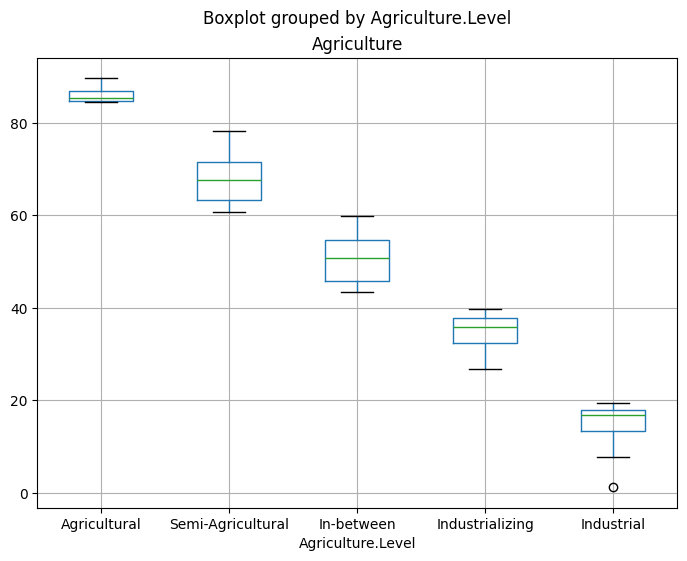

In [55]:
# -----------------------------------------------
# Distribution of agriculture levels per category
# -----------------------------------------------

agriculture_level = []
for agri in swiss["Agriculture"]:
    if agri <= 20:
        agriculture_level.append("Industrial")
    elif agri <= 40:
        agriculture_level.append("Industrializing")
    elif agri <= 60:
        agriculture_level.append("In-between")
    elif agri <= 80:
        agriculture_level.append("Semi-Agricultural")
    else:
        agriculture_level.append("Agricultural")

# Add agriculture_level to swiss
swiss["Agriculture.Level"] = agriculture_level

# Create boxplot to visualize the distribution of sco
order = ["Agricultural", "Semi-Agricultural", "In-between", "Industrializing", "Industrial"]
swiss["Agriculture.Level"] = pd.Categorical(swiss["Agriculture.Level"], categories=order, ordered=True)
swiss.sort_values("Agriculture.Level").boxplot(column="Agriculture", by="Agriculture.Level", figsize=(8,6))

<Axes: title={'center': 'Fertility'}, xlabel='Agriculture.Level'>

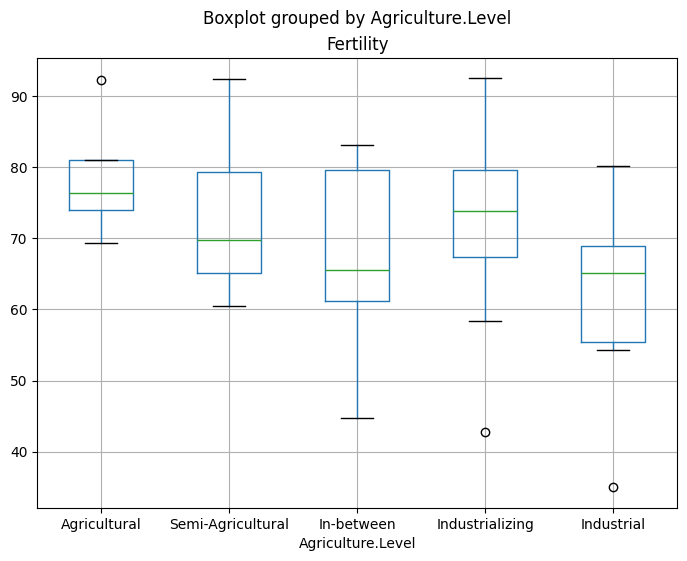

In [44]:
# ---------------------------------------------
# Agriculture level's effect on fertility rates
# ---------------------------------------------

swiss.boxplot(column="Fertility", by="Agriculture.Level", figsize=(8,6))


<Axes: xlabel='Agriculture', ylabel='Fertility'>

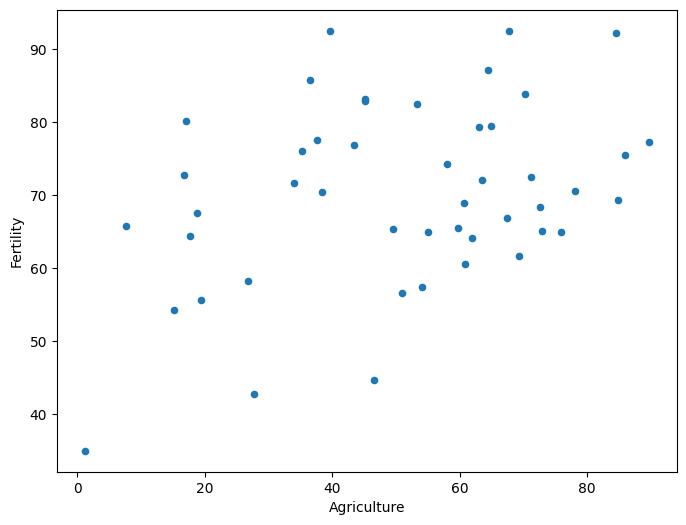

In [54]:
# ---------------------------------------------------------------------
# Agriculture level's effect on fertility rates (increased granularity)
# ---------------------------------------------------------------------

swiss.plot.scatter(x="Agriculture", y="Fertility", figsize=(8,6))


# Do the amount of catholics in a province have an effect on fertility?


<Axes: xlabel='Catholic', ylabel='Fertility'>

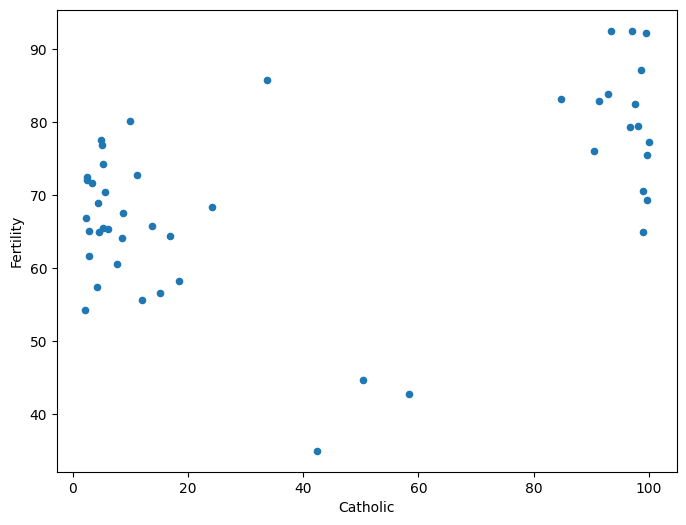

In [45]:
# -------------------------------------------------
# Percentage of catholics effect on fertility rates
# -------------------------------------------------

swiss.plot.scatter(x="Catholic", y="Fertility", figsize=(8,6))


# Does the Infant Mortality Rate have any effect on fertility?

<Axes: xlabel='Infant.Mortality', ylabel='Fertility'>

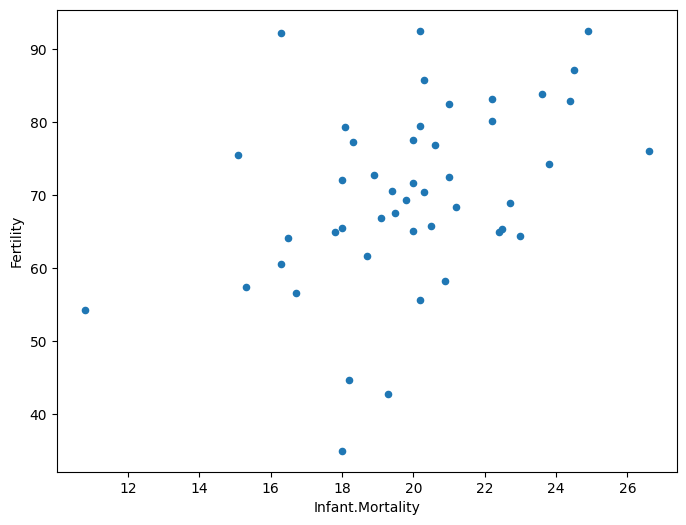

In [46]:
# ---------------------------------------------
# Infant Mortaility's effect on fertility rates
# ---------------------------------------------

swiss.plot.scatter(x="Infant.Mortality", y="Fertility", figsize=(8,6))


# Does the level of education achieved by draftees have any relation to fertility levels?

<Axes: xlabel='Education', ylabel='Fertility'>

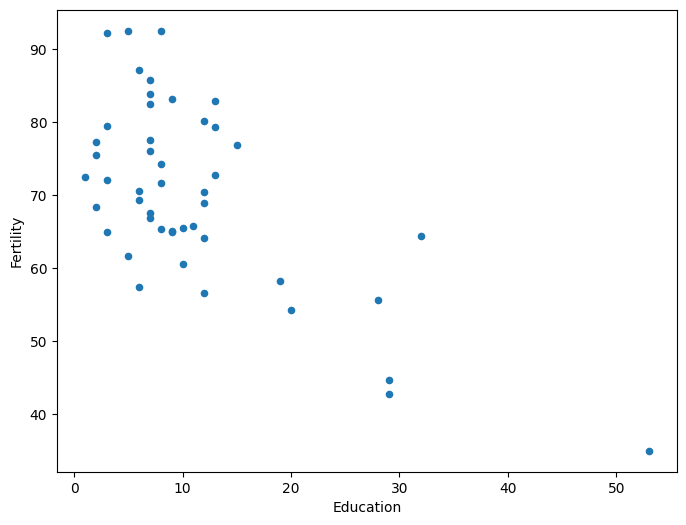

In [47]:
# -------------------------------------------
# Education level's effect on fertility rates
# -------------------------------------------

swiss.plot.scatter(x="Education", y="Fertility", figsize=(8,6))


# Conclusions

While the majority of the relationships are not very strong, the data shows some general patterns:

1.   The more people who work in agriculture, the higher the the fertility level.
2.   The more catholics in a province (vs prodestants), the higher the fertility level.
3.   The higher the infant mortality rate, the higher the fertility level.
4.   The lower the amount of education achieved by draftees, the higher the fertility rate.

in other words...

1.   Fertility is proportional to agriculture
2.   Fertility is proprotional to catholocism
3.   Fertility is proportional to infant mortality
4.   Fertility is inversely proportional to education levels

Again, these relationships are not very strong. However, they are consistent with basic demographic patterns.

Birth rates are typically higher in agricultural communities. Children can work to either help out the farm or upkeep the household, so the more children you have, the more laborers you have on the farm. A reduction in the amount of people working in agriculture is typically associated with the start of industrialization. Less people work in agriculture since there are now more efficent methods for farming, typically involving basic machinery. This would mean that less laborers are required for farms, therefore less children are needed.

Catholocism praises traditional marriges and discourages contraceptives and abortions. This would help explain the small (but not insigficant) increase in fertility rates between communities that are predominantly catholic in contrast to those predominantly prodestant.

The higher the infant mortality rates, the higher the fertility rate, as women have more children to make up for the ones that didn't make it to an age where they would be useful to the family. (Yes I am aware this makes me sound like a monster, but it's just how this works)

Higher education levels are associated with lower fertility rates. This usually attributed to people being more knowledgeable about contraceptives, and having the possiblilty of more opportunties outside the household.


# Other relationships between variables

This section was more for my own curiosity than anything else. No one can stop me.

<Axes: title={'center': 'Catholic'}, xlabel='Agriculture.Level'>

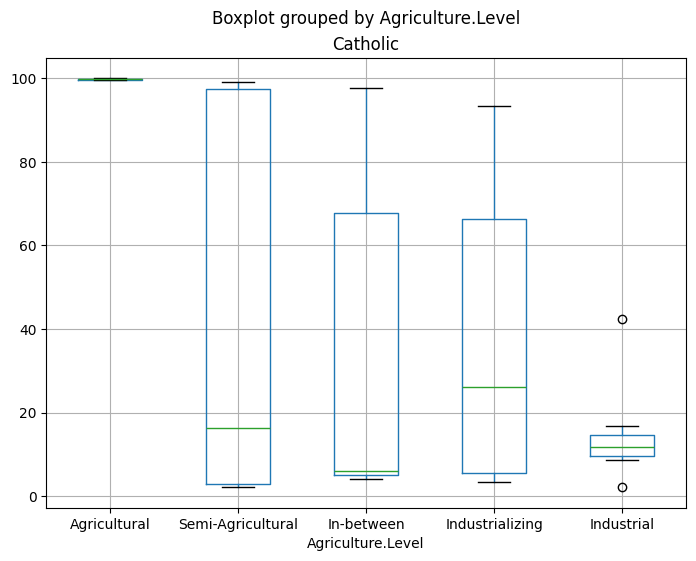

In [48]:
# -------------------------------------------------------
# Percentage of catholics relation to agricultural levels
# -------------------------------------------------------

swiss.boxplot(column="Catholic", by="Agriculture.Level", figsize=(8,6))


<Axes: title={'center': 'Infant.Mortality'}, xlabel='Agriculture.Level'>

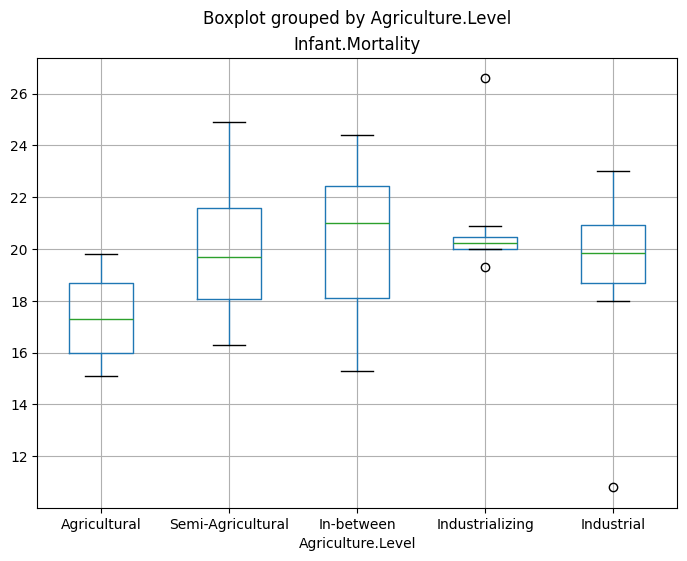

In [49]:
# ---------------------------------------------------
# Infant Mortaility's relation to agricultural levels
# ---------------------------------------------------

swiss.boxplot(column="Infant.Mortality", by="Agriculture.Level", figsize=(8,6))


<Axes: xlabel='Catholic', ylabel='Infant.Mortality'>

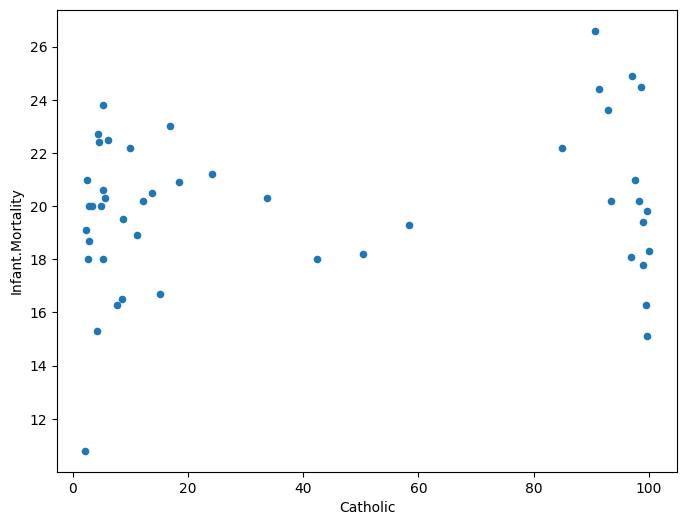

In [50]:
# --------------------------------------------------
# Infant Mortaility's relation to Catholocism levels
# I expect this to have no relation
# --------------------------------------------------

swiss.plot.scatter(x="Catholic", y="Infant.Mortality", figsize=(8,6))


<Axes: title={'center': 'Education'}, xlabel='Agriculture.Level'>

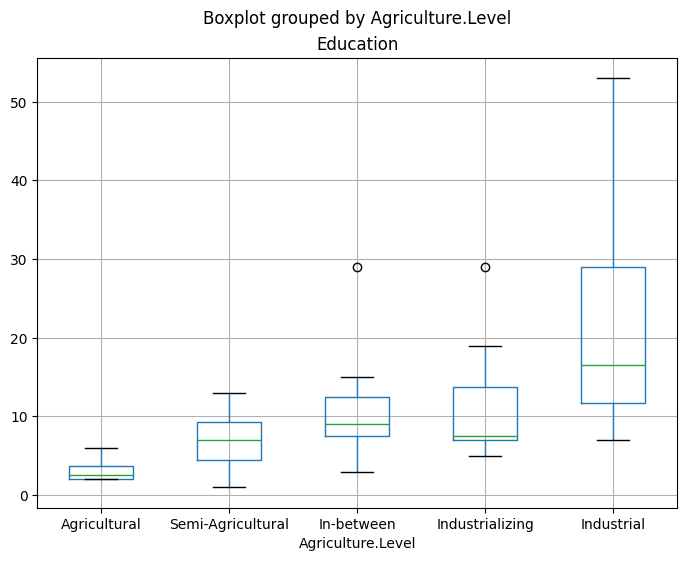

In [51]:
# -------------------------------------------------
# Education level's relation to agricultural levels
# -------------------------------------------------

swiss.boxplot(column="Education", by="Agriculture.Level", figsize=(8,6))


<Axes: xlabel='Catholic', ylabel='Education'>

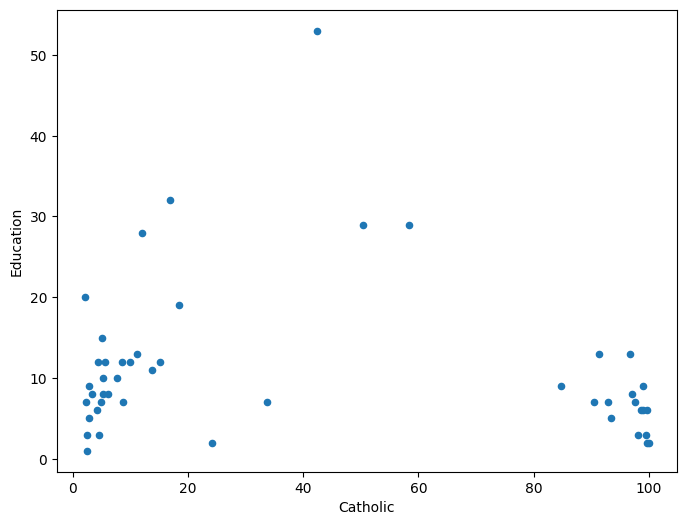

In [52]:
# -----------------------------------------
# Education level's relation to catholocism
# -----------------------------------------

swiss.plot.scatter(x="Catholic", y="Education", figsize=(8,6))


<Axes: xlabel='Education', ylabel='Infant.Mortality'>

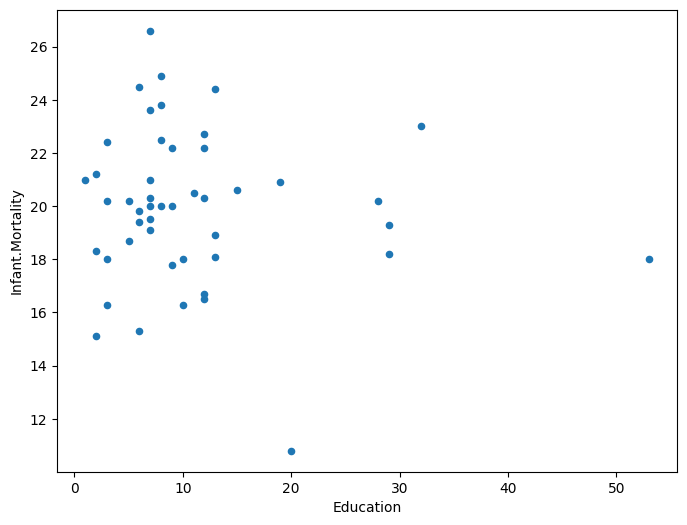

In [53]:
# ----------------------------------------------
# Education level's relation to infant mortality
# ----------------------------------------------

swiss.plot.scatter(x="Education", y="Infant.Mortality", figsize=(8,6))
